# Determinantes Individuales del Evento de Corrupción en el Perú
## Un enfoque microeconométrico mediante modelo Logit

AutorQuinta Quintana, Ronald Dinhobre]  
Base de datos: ENAHO  
Método: Máxima Verosimilitud  
Software: Python

## 1. Introducción

La corrupción constituye uno de los principales problemas institucionales en el Perú, afectando la eficiencia del gasto público, la confianza en las instituciones y el bienestar de los ciudadanos. A nivel microeconómico, los actos de corrupción se manifiestan frecuentemente en la solicitud de pagos indebidos (coimas) por parte de funcionarios públicos durante la provisión de servicios.

El presente estudio tiene como objetivo analizar los factores socioeconómicos, demográficos y territoriales asociados a la probabilidad de experimentar un evento de corrupción a nivel individual, utilizando información proveniente de la Encuesta Nacional de Hogares (ENAHO).

Dado que la variable de interés es dicotómica (ocurrencia o no de solicitud de coima), se emplea un modelo Logit estimado por máxima verosimilitud, lo que permite modelar adecuadamente la probabilidad condicional del evento.

## 2. Metodología

Se estima un modelo Logit debido a que la variable dependiente es dicotómica.

La forma funcional es:

\[
P(Y_i = 1 | X_i) = \frac{e^{X_i\beta}}{1 + e^{X_i\beta}}
\]

Los parámetros se estiman mediante máxima verosimilitud.

In [1]:
import pandas as pd
import numpy as np


In [2]:
df_gob = pd.read_csv(
    "MODULO_84.csv",
    encoding="latin-1",
    low_memory=False
)

In [3]:
df_empleo = pd.read_csv(
    "MODULO_500.csv",
    encoding="latin-1",
    low_memory=False
)

In [4]:
df_educacion = pd.read_csv(
    "MODULO_300.csv",
    encoding="latin-1",
    low_memory=False
)

In [5]:
df_hogar = pd.read_csv(
    "MODULO_200.csv",
    encoding="latin-1",
    low_memory=False
)

In [6]:
df_sumaria = pd.read_csv(
    "SUMARIA.csv",
    encoding="latin-1",
    low_memory=False
)

In [7]:
#GENERAR VARIABLE DEPENDIENTE

In [8]:
vars_p2c = [f"P2C${str(i).zfill(2)}" for i in range(1, 18)]
df_gob[vars_p2c] = df_gob[vars_p2c].apply(pd.to_numeric, errors='coerce')
df_gob["LE_SOLICITARON_COIMA"] = (
    ~(df_gob[vars_p2c].eq(4).all(axis=1))
).astype(int)



In [9]:
df_gob[vars_p2c] = df_gob[vars_p2c].fillna(4)

df_gob["LE_SOLICITARON_COIMA"] = (
    ~(df_gob[vars_p2c].eq(4).all(axis=1))
).astype(int)


In [10]:
df_gob["LE_SOLICITARON_COIMA"].value_counts()


LE_SOLICITARON_COIMA
0    33285
1      406
Name: count, dtype: int64

In [11]:
df = df_gob.rename(columns={'LE_SOLICITARON_COIMA': 'eventoCorrupcion'})


In [12]:
#LIMPIEZA DE DATOS

In [13]:
#ELIMINAR OBSERVACIONES QUE NO HICIERON USO DE NINGUNA INSTITUCIÓN PÚBLICA

In [14]:
df_gob["USO_INST"] = 0

In [15]:
vars_p2b = [f"P2B${str(i).zfill(2)}" for i in range(1, 18)]


In [16]:
df_gob[vars_p2b] = df_gob[vars_p2b].apply(
    pd.to_numeric, errors="coerce"
)

In [17]:
total_uso_valor = df_gob[vars_p2b].sum(axis=1, skipna=True)


In [18]:
df_gob["USO_INST"] = 0
df_gob.loc[total_uso_valor == 34, "USO_INST"] = 1


In [19]:
df_gob["USO_INST"].value_counts()


USO_INST
0    25078
1     8613
Name: count, dtype: int64

In [20]:
(total_uso_valor == 34).sum()


8613

In [21]:
df_gob = df_gob.drop(columns=["total_uso_valor"], errors="ignore")

In [22]:
df_gob = df_gob[df_gob["USO_INST"] != 1]

In [23]:
df_gob.shape[0]

25078

In [24]:
#ELIMINAR OBSERVACIONES MAYORES DE 70 AÑOS

In [25]:
df_gob["P208_01"] = pd.to_numeric(df_gob["P208_01"], errors="coerce")


In [26]:
df_gob = df_gob[df_gob["P208_01"] <= 71]

In [27]:
df_gob.shape[0]

18291

In [28]:
#MERGE

In [29]:
keys_persona = ["CONGLOME", "VIVIENDA", "HOGAR", "CODPERSO"]

df = df_gob.copy()

df = df.merge(
    df_educacion,
    on=keys_persona,
    how="inner"
)

In [30]:
df = df.merge(
    df_hogar,
    on=keys_persona,
    how="inner"
)

In [31]:
cols_to_drop = {
    'AÑO','CODTAREA','CODTIEMPO','DOMINIO','ESTRATO','FACPOB07','MES',
    'NCONGLOME','OCUPAC_R3','OCUPAC_R4','P201P','P203','P203A','P203B',
    'P204','P205','P206','P207','P208A','P208B','P209','P210','P211A',
    'P211D','P212','P213','P214','P215','P216','P217','RAMA_R3','RAMA_R4',
    'SUB_CONGLOME','T211','TICUEST01','UBIGEO'
}

cols_to_drop = cols_to_drop.intersection(df_hogar.columns)

df_hogar_clean = df_hogar.drop(columns=cols_to_drop)


In [32]:
df = df.merge(
    df_hogar_clean,
    on=keys_persona,
    how="inner"
)


In [33]:
cols_to_drop = df_empleo.columns.intersection(df.columns)
cols_to_drop = cols_to_drop.difference(keys_persona)

df_empleo_clean = df_empleo.drop(columns=cols_to_drop)


In [34]:
df = df.merge(
    df_empleo_clean,
    on=keys_persona,
    how="inner"
)

In [35]:
cols_sumaria_drop = {
    'AÑO','MES','UBIGEO','DOMINIO','ESTRATO',
    'NCONGLOME','SUB_CONGLOME'
}

cols_sumaria_drop = cols_sumaria_drop.intersection(df_sumaria.columns)

df_sumaria_clean = df_sumaria.drop(columns=cols_sumaria_drop)


In [36]:
keys_hogar = ["CONGLOME", "VIVIENDA", "HOGAR"]

In [37]:
df = df.merge(
    df_sumaria_clean,
    on=keys_hogar,
    how="inner"
)


In [38]:
cols_x = [c for c in df.columns if c.endswith("_x")]
cols_x
df = df.rename(columns={c: c.replace("_x", "") for c in cols_x})
cols_y = [c for c in df.columns if c.endswith("_y")]
df = df.drop(columns=cols_y)

In [39]:
df = df.loc[:, ~df.columns.duplicated()]


In [40]:
df.shape[0]


18291

In [41]:
#RENOMBRAR VARIABLES

In [42]:
df = df.rename(columns={
    "P207": "sexo",
    "P208A": "edad",
    "P209": "estadoCivil",
    "DOMINIO": "regionNatural",
    "INGHOG2D": "ingresosNetos",
    "ESTRATO": "ciudadRural",
    "P300A": "idioma",
    "P501": "empleo",
    "P301_01": "nivelEducativo"
})


In [43]:
#Estado civil

In [44]:
df["estadoCivil"].value_counts(dropna=False)


estadoCivil
1    5664
2    4509
5    3564
6    3379
3    1007
4     168
Name: count, dtype: int64

In [45]:
df["estadoCivil"] = (
    df["estadoCivil"]
    .astype(str)
    .str.strip()
)


In [46]:
df["solo"] = np.nan

# No solo (conviviente, casado)
df.loc[df["estadoCivil"].isin(["1", "2"]), "solo"] = 0

# Solo (viudo, divorciado, separado, soltero)
df.loc[df["estadoCivil"].isin(["3", "4", "5", "6"]), "solo"] = 1


In [47]:
pd.crosstab(df["estadoCivil"], df["solo"], dropna=False)


solo,0.0,1.0
estadoCivil,,
1,5664,0
2,4509,0
3,0,1007
4,0,168
5,0,3564
6,0,3379


In [48]:
df["estadoCivil"] = pd.to_numeric(df["estadoCivil"], errors="coerce")

In [49]:
#SEXO

In [50]:
df["sexo"].value_counts(dropna=False)


sexo
2    11160
1     7131
Name: count, dtype: int64

In [51]:
df["mujer"] = np.nan
df.loc[df["sexo"] == 1, "mujer"] = 0
df.loc[df["sexo"] == 2, "mujer"] = 1


In [52]:
df["mujer"].value_counts(dropna=False)


mujer
1.0    11160
0.0     7131
Name: count, dtype: int64

In [53]:
#IDIOMA

In [54]:
df["idioma"].value_counts(dropna=False)


idioma
4     13513
1      3885
2       418
11      124
3       105
10      103
12       51
6        30
13       15
14       14
15       13
9         9
8         6
7         3
99        2
Name: count, dtype: int64

In [55]:
df["castellano"] = np.nan
df.loc[df["idioma"] == 4, "castellano"] = 1
df.loc[(df["idioma"] != 4) & (df["idioma"] != 99), "castellano"] = 0


In [56]:
df["castellano"].value_counts(dropna=False)


castellano
1.0    13513
0.0     4776
NaN        2
Name: count, dtype: int64

In [57]:
#POBRE

In [58]:
df["pobre"] = np.nan
df.loc[df["POBREZA"].isin([1, 2]), "pobre"] = 1
df.loc[df["POBREZA"] == 3, "pobre"] = 0
df["pobre"].value_counts(dropna=False)

pobre
0.0    14549
1.0     3742
Name: count, dtype: int64

In [59]:
#EMPLEO

In [60]:
df["empleo"].value_counts(dropna=False)

empleo
1    14032
2     4254
9        5
Name: count, dtype: int64

In [61]:
df["empleado"] = np.nan
df.loc[df["empleo"] == 1, "empleado"] = 1
df.loc[df["empleo"] == 2, "empleado"] = 0
df["empleado"].value_counts(dropna=False)

empleado
1.0    14032
0.0     4254
NaN        5
Name: count, dtype: int64

In [62]:
#RURAL

In [63]:
df["rural"] = np.nan
df.loc[df["ciudadRural"].isin([7, 8]), "rural"] = 1
df.loc[df["ciudadRural"].isin([1, 2, 3, 4, 5, 6]), "rural"] = 0
df["rural"].value_counts(dropna=False)


rural
0.0    12544
1.0     5747
Name: count, dtype: int64

In [64]:
df["lima"] = np.nan
df.loc[df["regionNatural"].isin([8]), "lima"] = 1
df.loc[df["regionNatural"].isin([1, 2, 3, 4, 5, 6, 7]), "lima"] = 0
df["lima"].value_counts(dropna=False)


lima
0.0    17270
1.0     1021
Name: count, dtype: int64

In [65]:
df["solo"] = np.nan
df.loc[df["estadoCivil"].isin([3, 4, 5, 6]), "solo"] = 1
df.loc[df["estadoCivil"].isin([1, 2]), "solo"] = 0
df["solo"].value_counts(dropna=False)


solo
0.0    10173
1.0     8118
Name: count, dtype: int64

In [66]:
#AÑOS DE EDUCACION

In [67]:
df["edu"] = np.nan


In [68]:
df["P301B"] = pd.to_numeric(df["P301B"], errors="coerce")
df["P301C"] = pd.to_numeric(df["P301C"], errors="coerce")
df["P301A"] = pd.to_numeric(df["P301A"], errors="coerce")


In [69]:
df["edu"] = np.nan
mask = df["P301A"]

df.loc[mask == 1, "edu"] = 0
df.loc[mask == 2, "edu"] = df["P301B"]
df.loc[mask == 3, "edu"] = df[["P301B", "P301C"]].max(axis=1)
df.loc[mask == 4, "edu"] = 6
df.loc[mask.isin([5, 6]), "edu"] = 6 + df["P301B"]
df.loc[mask.isin([7, 8, 9, 10]), "edu"] = 11 + df["P301B"]
df.loc[mask == 11, "edu"] = 16 + df["P301B"]

# códigos no válidos (12, 74, etc.)
df.loc[~mask.isin([1,2,3,4,5,6,7,8,9,10,11]), "edu"] = np.nan


In [70]:
pd.crosstab(df["P301A"], df["edu"].isna(), dropna=False)


edu,False,True
P301A,,
1,777,0
2,14,0
3,2540,0
4,2297,0
5,2115,0
6,4816,0
7,952,0
8,1847,0
9,966,0


In [71]:
df["edu"].describe()


count    18285.000000
mean         9.595789
std          4.708498
min          0.000000
25%          6.000000
50%         11.000000
75%         13.000000
max         19.000000
Name: edu, dtype: float64

In [72]:
df["edu"]


0        18.0
1        14.0
2         8.0
3        14.0
4        11.0
         ... 
18286     2.0
18287    14.0
18288    12.0
18289    12.0
18290    11.0
Name: edu, Length: 18291, dtype: float64

In [73]:
#INGRESOS

In [74]:
df["ln_ingresos"] = np.where(
    df["ingresosNetos"] > 0,
    np.log(df["ingresosNetos"]),
    np.nan
)


In [75]:
#GLOBAL

In [76]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

variables = [
    "ln_ingresos",
    "edu",
    "mujer",
    "castellano",
    "edad",
    "pobre",
    "empleado",
    "rural",
    "solo",
    "lima"
]


In [77]:
#LOGIT

In [78]:
df = df.rename(columns={'LE_SOLICITARON_COIMA': 'eventoCorrupcion'})

In [79]:
# Variable dependiente
y = df["eventoCorrupcion"]

# Variables explicativas
X = df[variables]

# Agregar constante (intercepto)
X = sm.add_constant(X)

# Eliminar observaciones con missing (como hace Stata)
data_model = pd.concat([y, X], axis=1).dropna()

y_clean = data_model["eventoCorrupcion"]
X_clean = data_model.drop(columns="eventoCorrupcion")


In [80]:
print(X_clean.shape)
print(y_clean.shape)


(18281, 11)
(18281,)


## 3. Estadística Descriptiva

Se trabaja con una muestra de 18,281 individuos.  
La incidencia del evento de corrupción es aproximadamente 2%, lo que indica un evento poco frecuente.

In [81]:
logit_model = sm.Logit(y_clean, X_clean)
logit_res = logit_model.fit(disp=False)

print(logit_res.summary())


                           Logit Regression Results                           
Dep. Variable:       eventoCorrupcion   No. Observations:                18281
Model:                          Logit   Df Residuals:                    18270
Method:                           MLE   Df Model:                           10
Date:                Tue, 03 Mar 2026   Pseudo R-squ.:                 0.07503
Time:                        13:04:06   Log-Likelihood:                -1748.3
converged:                       True   LL-Null:                       -1890.1
Covariance Type:            nonrobust   LLR p-value:                 4.450e-55
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -5.7032      0.865     -6.596      0.000      -7.398      -4.009
ln_ingresos     0.1903      0.082      2.329      0.020       0.030       0.351
edu             0.0934      0.017      5.559    

In [82]:
#Predict plogit1

In [83]:
df.loc[data_model.index, "plogit1"] = logit_res.predict(X_clean)

# ver resumen
df["plogit1"].describe()


count    18281.000000
mean         0.021388
std          0.020345
min          0.000763
25%          0.007729
50%          0.015404
75%          0.028357
max          0.220433
Name: plogit1, dtype: float64

## 4. Resultados del Modelo Logit

El ingreso y la educación presentan efectos positivos y estadísticamente significativos.

Ser mujer reduce la probabilidad del evento.

Residir en Lima incrementa la probabilidad de experimentar una solicitud de coima.

In [84]:
#EFECTOS MARGINALES PROMEDIO

In [85]:
margins_mean = logit_res.get_margeff()
print(margins_mean.summary())


        Logit Marginal Effects       
Dep. Variable:       eventoCorrupcion
Method:                          dydx
At:                           overall
                 dy/dx    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
ln_ingresos     0.0039      0.002      2.317      0.020       0.001       0.007
edu             0.0019      0.000      5.393      0.000       0.001       0.003
mujer          -0.0143      0.002     -6.287      0.000      -0.019      -0.010
castellano     -0.0025      0.003     -0.819      0.413      -0.008       0.003
edad           -0.0004   8.26e-05     -4.763      0.000      -0.001      -0.000
pobre          -0.0050      0.004     -1.391      0.164      -0.012       0.002
empleado        0.0052      0.003      1.873      0.061      -0.000       0.011
rural          -0.0097      0.003     -2.848      0.004      -0.016      -0.003
solo           -0.0022      0.002     -0.963    

In [86]:
#EFECTOS MARGINALES dY/dX

In [87]:
margins_dydx = logit_res.get_margeff(at="overall", method="dydx")
print(margins_dydx.summary())


        Logit Marginal Effects       
Dep. Variable:       eventoCorrupcion
Method:                          dydx
At:                           overall
                 dy/dx    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
ln_ingresos     0.0039      0.002      2.317      0.020       0.001       0.007
edu             0.0019      0.000      5.393      0.000       0.001       0.003
mujer          -0.0143      0.002     -6.287      0.000      -0.019      -0.010
castellano     -0.0025      0.003     -0.819      0.413      -0.008       0.003
edad           -0.0004   8.26e-05     -4.763      0.000      -0.001      -0.000
pobre          -0.0050      0.004     -1.391      0.164      -0.012       0.002
empleado        0.0052      0.003      1.873      0.061      -0.000       0.011
rural          -0.0097      0.003     -2.848      0.004      -0.016      -0.003
solo           -0.0022      0.002     -0.963    

In [88]:
#EFECTOS MARGINALES EN LA MEDIA

In [89]:
margins_atmeans = logit_res.get_margeff(at="mean", method="dydx")
print(margins_atmeans.summary())


        Logit Marginal Effects       
Dep. Variable:       eventoCorrupcion
Method:                          dydx
At:                              mean
                 dy/dx    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
ln_ingresos     0.0027      0.001      2.320      0.020       0.000       0.005
edu             0.0013      0.000      5.846      0.000       0.001       0.002
mujer          -0.0100      0.002     -6.588      0.000      -0.013      -0.007
castellano     -0.0017      0.002     -0.820      0.412      -0.006       0.002
edad           -0.0003   5.54e-05     -4.979      0.000      -0.000      -0.000
pobre          -0.0035      0.003     -1.398      0.162      -0.008       0.001
empleado        0.0037      0.002      1.881      0.060      -0.000       0.008
rural          -0.0068      0.002     -2.917      0.004      -0.011      -0.002
solo           -0.0015      0.002     -0.966    

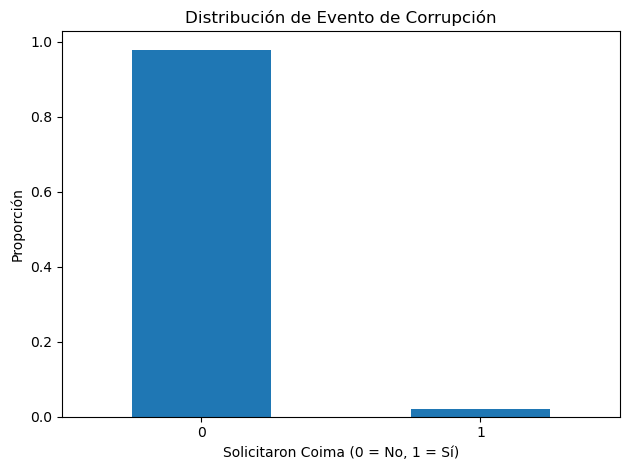

In [90]:
import matplotlib.pyplot as plt

df["eventoCorrupcion"].value_counts(normalize=True).plot(kind="bar")

plt.title("Distribución de Evento de Corrupción")
plt.xlabel("Solicitaron Coima (0 = No, 1 = Sí)")
plt.ylabel("Proporción")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

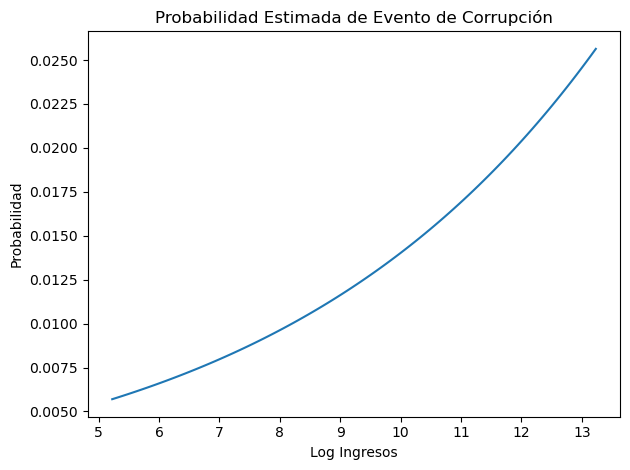

In [91]:
import numpy as np
import pandas as pd

# Rango de ln_ingresos
x_range = np.linspace(
    X_clean["ln_ingresos"].min(),
    X_clean["ln_ingresos"].max(),
    100
)

# Crear base manteniendo otras variables en su media
X_mean = X_clean.mean()
X_plot = pd.DataFrame([X_mean] * 100)
X_plot["ln_ingresos"] = x_range

# Predicción
pred_prob = logit_res.predict(X_plot)

plt.plot(x_range, pred_prob)
plt.title("Probabilidad Estimada de Evento de Corrupción")
plt.xlabel("Log Ingresos")
plt.ylabel("Probabilidad")
plt.tight_layout()
plt.show()

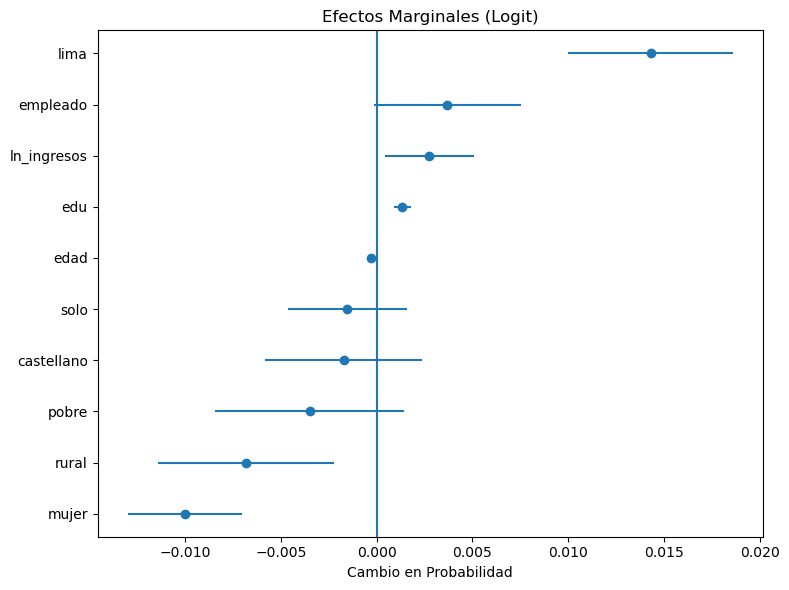

In [92]:
import matplotlib.pyplot as plt

# Obtener efectos marginales
margins = logit_res.get_margeff(at="mean")
margins_df = margins.summary_frame()

# Eliminar constante si existe
if "const" in margins_df.index:
    margins_df = margins_df.drop(index="const")

# Ordenar efectos
margins_df = margins_df.sort_values(by="dy/dx")

# Graficar
plt.figure(figsize=(8,6))

plt.errorbar(
    margins_df["dy/dx"],
    margins_df.index,
    xerr=1.96 * margins_df["Std. Err."],
    fmt="o"
)

plt.axvline(x=0)
plt.title("Efectos Marginales (Logit)")
plt.xlabel("Cambio en Probabilidad")
plt.tight_layout()
plt.show()

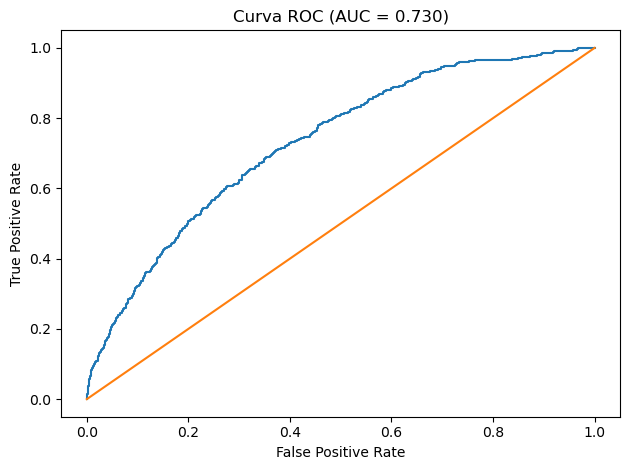

In [93]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probabilidades predichas
y_pred_prob = logit_res.predict(X_clean)

# ROC
fpr, tpr, _ = roc_curve(y_clean, y_pred_prob)
auc = roc_auc_score(y_clean, y_pred_prob)

plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1])
plt.title(f"Curva ROC (AUC = {auc:.3f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.tight_layout()
plt.show()

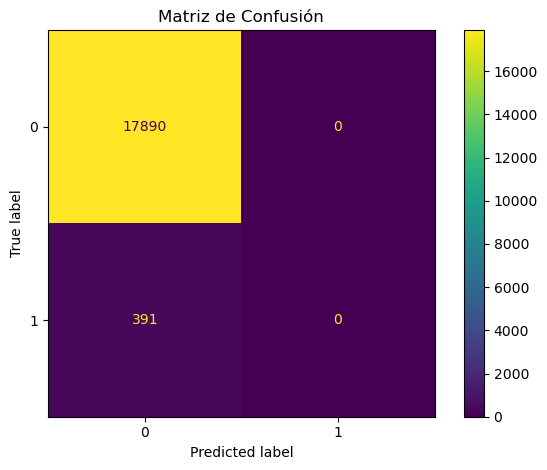

In [94]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Clasificación con umbral 0.5
y_pred_class = (y_pred_prob >= 0.5).astype(int)

cm = confusion_matrix(y_clean, y_pred_class)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Matriz de Confusión")
plt.tight_layout()
plt.show()

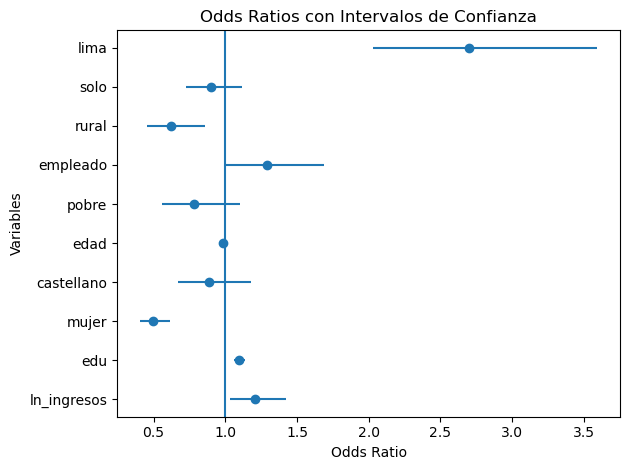

In [95]:
import numpy as np

params = logit_res.params.drop("const")
conf = logit_res.conf_int().drop("const")

odds_ratios = np.exp(params)
conf_odds = np.exp(conf)

plt.errorbar(
    odds_ratios,
    odds_ratios.index,
    xerr=[
        odds_ratios - conf_odds[0],
        conf_odds[1] - odds_ratios
    ],
    fmt="o"
)

plt.axvline(x=1)
plt.title("Odds Ratios con Intervalos de Confianza")
plt.xlabel("Odds Ratio")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()

## 5. Evaluación del Modelo

Dado que el evento es poco frecuente (~2%), la tasa de aciertos no es una medida suficiente.

El AUC permite evaluar la capacidad discriminatoria del modelo.

## 6. Conclusiones

El presente estudio analizó los determinantes individuales asociados a la probabilidad de experimentar un evento de corrupción utilizando un modelo Logit estimado por máxima verosimilitud.

Los resultados muestran que variables socioeconómicas y territoriales influyen significativamente en la probabilidad del evento. En particular, el ingreso y el nivel educativo presentan efectos positivos y estadísticamente significativos, lo que sugiere que una mayor interacción institucional o mayor capacidad económica podría incrementar la exposición a solicitudes de coima.

Ser mujer y residir en zona rural reducen la probabilidad del evento, mientras que residir en Lima la incrementa significativamente. Asimismo, la edad muestra una relación negativa con la ocurrencia de corrupción.

Dado que el evento presenta baja incidencia en la muestra (~2%), los efectos marginales promedio permiten una interpretación más precisa en términos probabilísticos. La evaluación mediante la curva ROC confirma que el modelo posee capacidad discriminatoria adecuada para distinguir entre individuos expuestos y no expuestos al evento.

En conjunto, los resultados sugieren que la exposición institucional y el contexto territorial son factores relevantes en la ocurrencia de actos de corrupción a nivel individual.